# *Import Necessary Libraries*

In [23]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# *Load MNIST dataset*

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# *Normalize the Images*

In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [35]:
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))
x_train[0].shape

(28, 28, 1)

# *Display Images with Labels*

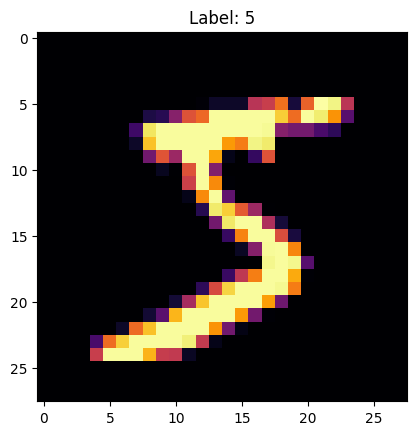

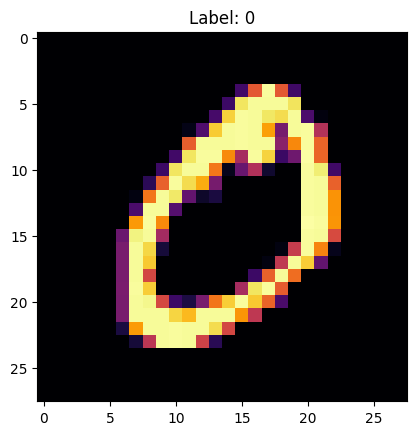

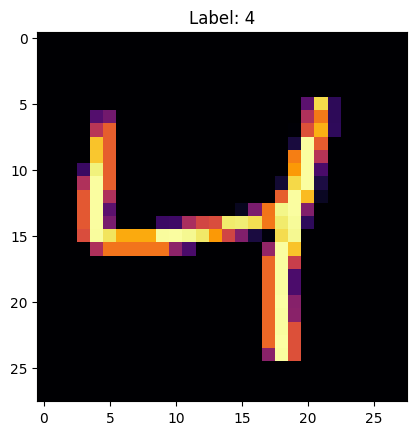

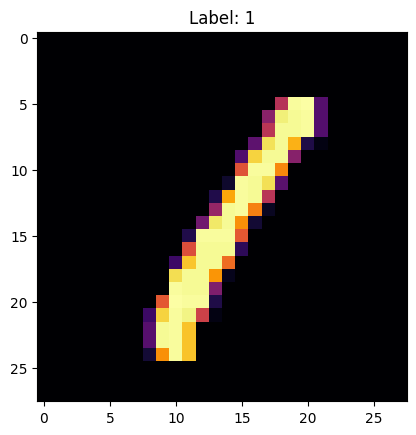

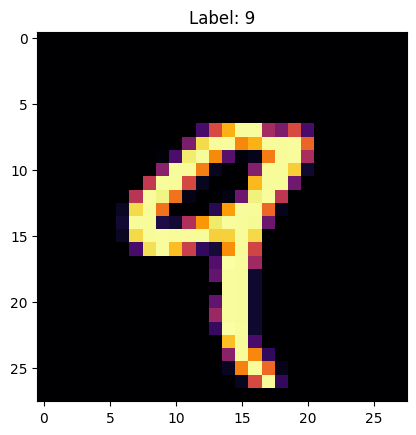

In [34]:
def display_image(index):
    plt.imshow(x_train[index].reshape(28, 28), cmap='inferno')
    plt.title(f"Label: {y_train[index]}")
    plt.show()

# Display some images
for i in range(5):
    display_image(i)

# *Build Neural Network Model*

In [37]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\INTEL\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# *Compile the Model*

In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# *Train the Model*

In [22]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9903 - loss: 0.0302
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9941 - loss: 0.0184
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9944 - loss: 0.0179
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9960 - loss: 0.0129
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9964 - loss: 0.0114


# *Evaluate the Model*

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0380 
Test accuracy: 0.9911999702453613


# *Predict the Results*

In [16]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# *Confusion Matrix*

tf.Tensor(
[[ 977    0    1    0    1    0    0    1    0    0]
 [   0 1129    2    2    0    0    1    1    0    0]
 [   0    0 1024    0    1    0    0    6    1    0]
 [   0    0    1 1005    0    2    0    0    2    0]
 [   0    0    0    0  978    0    0    0    1    3]
 [   1    0    0    7    0  879    1    1    0    3]
 [   2    2    0    0    2    1  950    0    1    0]
 [   0    1    4    2    0    0    0 1020    1    0]
 [   2    0    2    1    0    0    0    2  965    2]
 [   1    1    0    1   13    1    0    4    3  985]], shape=(10, 10), dtype=int32)


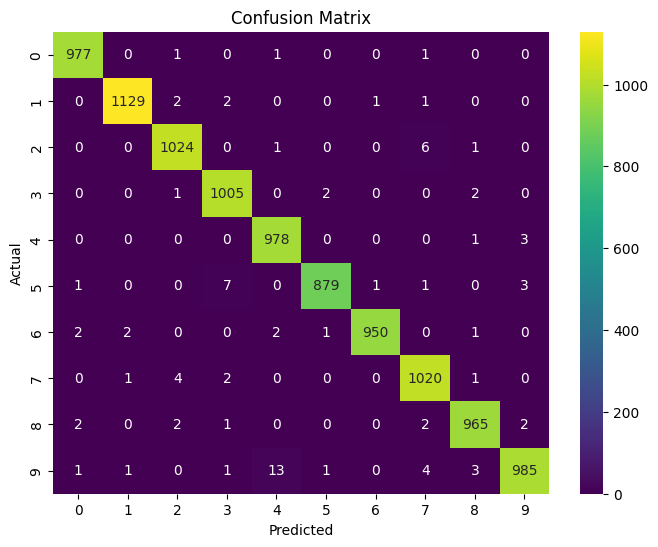

In [21]:
cm = tf.math.confusion_matrix(y_test, y_pred_classes)
print(cm)

# Plot the confusion matrix with a different color palette
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=[str(i) for i in range(10)], yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# *Conclusion*

### 1) We Imported Necessary Libraries.
### 2) We Loaded the MNIST Dataset from Keras.
### 3) We Normalize and Displayed the Images with Labels. 
### 4) We Builded the Neural Network Model.
### 5) We Compiled, Trained and Evaluated the Model. 
### 6) We Predicted the Results and Made Confusion Matrix on the Basis of Predicted Results By Model.